# Cross-species pathway inference in PlantMetWiki
## Case study: capsaicin biosynthesis in *Capsicum*

This notebook explores the capsaicin biosynthesis pathway (PC629) to illustrate how
PlantMetWiki can be used to:
1. Identify which *Capsicum* species are annotated in the knowledge graph
2. Compare annotation coverage across species within the same pathway
3. Use shared metabolites and reactions to infer annotation gaps (cross-species inference)
4. Answer the question: *Can the capsaicin pathway be reconstructed across Capsicum species
   by integrating annotations from related species that share substrates, products, and reactions?*

---

## How to run

**Step 1 — Start Virtuoso** (the RDF triplestore):
```bash
# From the Snorql-UI repository
cd ../Snorql-UI
docker compose up -d virtuoso
# Wait ~30 seconds, then check: http://localhost:8890/sparql
```

**Step 2 — Load the PlantMetWiki graphs** (if not already loaded):
```bash
# From the Snorql-UI repo
bash scripts/load-graphs/load-all.sh
```

**Step 3 — Run this notebook**:
```bash
conda activate plantmetwiki-rdf
jupyter notebook notebooks/cross_species_capsicum.ipynb
```

---

## Named graphs used

| Named graph | Content |
|---|---|
| `graph/pathways` | Core WikiPathways RDF: `wp:Pathway`, `wp:GeneProduct`, `wp:Protein`, `wp:Metabolite`, `wp:Conversion` |
| `graph/gpml-taxonomy-extra` | Per-DataNode species annotations (`wp:organism ncbi:XXXXX`) |
| `graph/ncbitaxon` | OBO Foundry NCBITaxon ontology for label resolution (`rdfs:label`) |

**SPARQL endpoint:** `http://localhost:8890/sparql`


---
## Setup

In [1]:
from SPARQLWrapper import SPARQLWrapper, JSON
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

plt.rcParams.update({'figure.dpi': 150, 'font.size': 10,
                     'font.family': 'sans-serif',
                     'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans']})

ENDPOINT = 'http://localhost:8890/sparql'
G_PW   = 'http://rdf-plantmetwiki.bioinformatics.nl/graph/pathways'
G_TAX  = 'http://rdf-plantmetwiki.bioinformatics.nl/graph/gpml-taxonomy-extra'
G_NCBI = 'http://rdf-plantmetwiki.bioinformatics.nl/graph/ncbitaxon'
WP     = 'http://vocabularies.wikipathways.org/wp#'

PREFIXES = """
PREFIX wp:      <http://vocabularies.wikipathways.org/wp#>
PREFIX dc:      <http://purl.org/dc/elements/1.1/>
PREFIX dcterms: <http://purl.org/dc/terms/>
PREFIX rdfs:    <http://www.w3.org/2000/01/rdf-schema#>
PREFIX ncbi:    <http://purl.obolibrary.org/obo/NCBITaxon_>
PREFIX cito:    <http://purl.org/spar/cito/>
"""

def sparql(query, timeout=120):
    sw = SPARQLWrapper(ENDPOINT)
    sw.setReturnFormat(JSON)
    sw.setTimeout(timeout)
    sw.setQuery(PREFIXES + query)
    rows = sw.query().convert()['results']['bindings']
    return pd.DataFrame([{k: v['value'] for k, v in r.items()} for r in rows])

def ensure_col(df, col, default=''):
    """Add column with default value if SPARQL OPTIONAL returned no bindings."""
    if col not in df.columns:
        df[col] = default
    return df

print('Ready. Endpoint:', ENDPOINT)


Ready. Endpoint: http://localhost:8890/sparql


---
## Step 1 — Which *Capsicum* species are in PlantMetWiki?

We first ask the knowledge graph for all species whose name contains "Capsicum".
Species labels are resolved from `graph/ncbitaxon` (OBO Foundry NCBITaxon ontology).


In [2]:
capsicum_species = sparql(f"""
SELECT DISTINCT ?taxon ?name (COUNT(DISTINCT ?node) AS ?annotated_nodes)
WHERE {{
  GRAPH <{G_TAX}> {{ ?node wp:organism ?taxon . FILTER(?taxon != ncbi:33090) }}
  GRAPH <{G_NCBI}> {{ ?taxon rdfs:label ?name . FILTER(CONTAINS(LCASE(?name), "capsicum")) }}
}}
GROUP BY ?taxon ?name
ORDER BY DESC(?annotated_nodes)
""")

capsicum_species['ncbi_id'] = capsicum_species['taxon'].str.extract(r'NCBITaxon_(\d+)')
capsicum_species['annotated_nodes'] = capsicum_species['annotated_nodes'].astype(int)
print(capsicum_species[['ncbi_id','name','annotated_nodes']].to_string(index=False))


ncbi_id                name  annotated_nodes
   4072     Capsicum annuum               71
  80379   Capsicum chinense               22
   4071            Capsicum                7
   4073 Capsicum frutescens                4


> **Observation:** Four *Capsicum* entries are present: the genus-level node (*Capsicum*, NCBITaxon:4071)
> and three species — *C. annuum* (4072), *C. chinense* (80379), and *C. frutescens* (4073).
> *Capsicum annuum* has the most annotated DataNodes overall, reflecting its status as the primary
> model pepper species in PlantCyc.


---
## Step 2 — How many pathways does each *Capsicum* species cover?

Each pathway a species "covers" means it has at least one directly annotated gene or
enzyme node (`wp:organism`) that is `dcterms:isPartOf` that pathway.


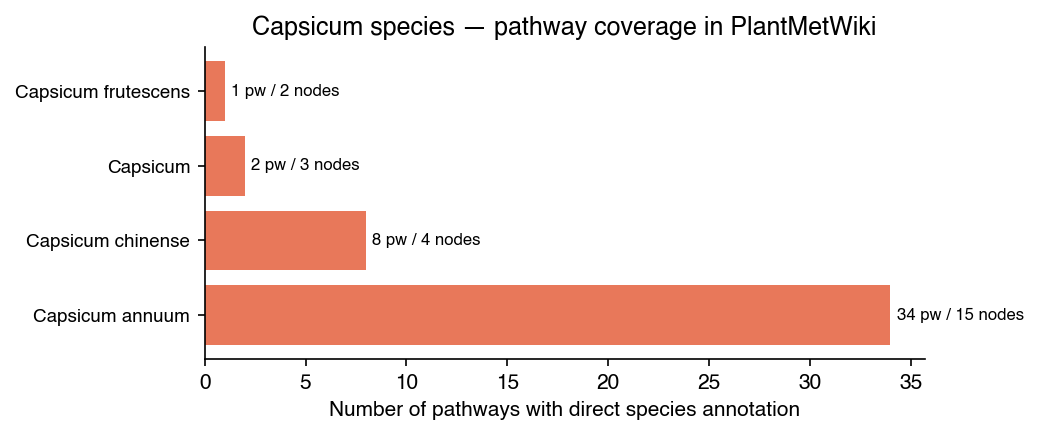

ncbi_id                name  pathways  annotated_nodes
   4072     Capsicum annuum        34               15
  80379   Capsicum chinense         8                4
   4071            Capsicum         2                3
   4073 Capsicum frutescens         1                2


In [3]:
capsicum_pathways = sparql(f"""
SELECT ?name ?taxon (COUNT(DISTINCT ?pw) AS ?pathways)
       (COUNT(DISTINCT ?node) AS ?annotated_nodes)
WHERE {{
  GRAPH <{G_TAX}> {{ ?node wp:organism ?taxon . FILTER(?taxon != ncbi:33090) }}
  GRAPH <{G_PW}>  {{ ?node dcterms:isPartOf ?pw . ?pw a wp:Pathway }}
  GRAPH <{G_NCBI}> {{ ?taxon rdfs:label ?name . FILTER(CONTAINS(LCASE(?name), "capsicum")) }}
}}
GROUP BY ?name ?taxon
ORDER BY DESC(?pathways)
""")

capsicum_pathways['ncbi_id']   = capsicum_pathways['taxon'].str.extract(r'NCBITaxon_(\d+)')
capsicum_pathways['pathways']  = capsicum_pathways['pathways'].astype(int)
capsicum_pathways['annotated_nodes'] = capsicum_pathways['annotated_nodes'].astype(int)

fig, ax = plt.subplots(figsize=(7, 3))
y = np.arange(len(capsicum_pathways))
ax.barh(y, capsicum_pathways['pathways'], color='#e8785a')
ax.set_yticks(y)
ax.set_yticklabels(capsicum_pathways['name'], fontsize=9)
ax.set_xlabel('Number of pathways with direct species annotation')
ax.set_title('Capsicum species — pathway coverage in PlantMetWiki')
for i, (n, nodes) in enumerate(zip(capsicum_pathways['pathways'], capsicum_pathways['annotated_nodes'])):
    ax.text(n + 0.3, i, f'{n} pw / {nodes} nodes', va='center', fontsize=8)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()
print(capsicum_pathways[['ncbi_id','name','pathways','annotated_nodes']].to_string(index=False))


> **Observation:** *Capsicum annuum* (NCBITaxon:4072) dominates with 34 pathways, far exceeding
> *C. chinense* (8), the genus *Capsicum* (2), and *C. frutescens* (1). This mirrors the
> curation depth of CapsicumCyc vs other PlantCyc databases.


---
## Step 3 — The capsaicin biosynthesis pathway (PC629)

We retrieve the pathway title and count of each entity type to understand its structure.


In [4]:
PW629 = 'http://rdf-plantmetwiki.bioinformatics.nl/pathways/PC629_r17.0.0_20260520160610'

pw_info = sparql(f"""
SELECT ?title ?type (COUNT(DISTINCT ?e) AS ?n)
WHERE {{
  GRAPH <{G_PW}> {{
    <{PW629}> a wp:Pathway ; dc:title ?title .
    ?e dcterms:isPartOf <{PW629}> ; a ?type .
    FILTER(STRSTARTS(STR(?type), "{WP}"))
  }}
}}
GROUP BY ?title ?type
ORDER BY DESC(?n)
""")

pw_info['type_short'] = pw_info['type'].str.replace(WP, 'wp:', regex=False)
pw_info['n'] = pw_info['n'].astype(int)
title = pw_info['title'].iloc[0]
print(f'Pathway: {title}  ({PW629.split("/")[-1]})')
print()
print(pw_info[['type_short','n']].to_string(index=False))


Pathway: capsaicin biosynthesis  (PC629_r17.0.0_20260520160610)

                 type_short  n
             wp:Interaction 56
                wp:DataNode 51
     wp:DirectedInteraction 47
              wp:Metabolite 27
              wp:Conversion 19
                 wp:Protein 13
               wp:Catalysis 12
wp:TranscriptionTranslation 11
             wp:GeneProduct 11
    wp:PublicationReference  5
             wp:Stimulation  4
              wp:Inhibition  1


> **Pathway structure:** PC629 contains 27 metabolites (`wp:Metabolite`), 19 biochemical conversions
> (`wp:Conversion`), 13 enzyme nodes (`wp:Protein`), 11 gene product nodes (`wp:GeneProduct`),
> and 12 catalytic links (`wp:Catalysis`). Five literature references support the pathway.
>
> The `wp:Catalysis` edges link each enzyme to the conversion it catalyses — they are the
> key edges for cross-species inference.


---
## Step 4 — Which species are annotated in the capsaicin biosynthesis pathway?

This query counts annotated DataNodes per species **within PC629 only**.


In [5]:
PW629 = 'http://rdf-plantmetwiki.bioinformatics.nl/pathways/PC629_r17.0.0_20260520160610'

# Two simple queries — Virtuoso does not support CASE WHEN in SPARQL
nodes_all = sparql(f"""
SELECT ?name ?taxon (COUNT(DISTINCT ?node) AS ?total_nodes)
WHERE {{
  GRAPH <{G_TAX}> {{ ?node wp:organism ?taxon . FILTER(?taxon != ncbi:33090) }}
  GRAPH <{G_PW}>  {{ ?node dcterms:isPartOf <{PW629}> }}
  GRAPH <{G_NCBI}> {{ ?taxon rdfs:label ?name }}
}}
GROUP BY ?name ?taxon
ORDER BY DESC(?total_nodes)
""")

genes_q = sparql(f"""
SELECT ?taxon (COUNT(DISTINCT ?node) AS ?genes)
WHERE {{
  GRAPH <{G_TAX}> {{ ?node wp:organism ?taxon . FILTER(?taxon != ncbi:33090) }}
  GRAPH <{G_PW}>  {{ ?node a wp:GeneProduct ; dcterms:isPartOf <{PW629}> }}
}}
GROUP BY ?taxon
""")

enzymes_q = sparql(f"""
SELECT ?taxon (COUNT(DISTINCT ?node) AS ?enzymes)
WHERE {{
  GRAPH <{G_TAX}> {{ ?node wp:organism ?taxon . FILTER(?taxon != ncbi:33090) }}
  GRAPH <{G_PW}>  {{ ?node a wp:Protein ; dcterms:isPartOf <{PW629}> }}
}}
GROUP BY ?taxon
""")

species_in_pw629 = (nodes_all
    .merge(genes_q,   on='taxon', how='left')
    .merge(enzymes_q, on='taxon', how='left'))
for c in ['total_nodes','genes','enzymes']:
    species_in_pw629[c] = pd.to_numeric(species_in_pw629[c], errors='coerce').fillna(0).astype(int)
species_in_pw629['ncbi_id'] = species_in_pw629['taxon'].str.extract(r'NCBITaxon_(\d+)')

print(species_in_pw629[['ncbi_id','name','genes','enzymes','total_nodes']].to_string(index=False))


ncbi_id                          name  genes  enzymes  total_nodes
   3702          Arabidopsis thaliana      3        3            6
  80379             Capsicum chinense      2        2            4
   4071                      Capsicum      1        2            3
   4006           Linum usitatissimum      1        1            2
   4073           Capsicum frutescens      1        1            2
  49390              Coffea canephora      1        1            2
  39947   Oryza sativa Japonica Group      1        1            2
   3879               Medicago sativa      1        1            2
   3544 Mesembryanthemum crystallinum      0        1            1


> **Key finding:** Nine species are represented in PC629.
> Notably, **`Capsicum annuum` (NCBITaxon:4072) is absent** — despite being the most
> pathway-rich *Capsicum* species overall (34 pathways), it has no directly annotated
> node in the capsaicin biosynthesis pathway.
>
> Annotations come from *C. chinense* (4 nodes), the genus *Capsicum* (3), *C. frutescens* (2),
> *Arabidopsis thaliana* (6), and four non-*Capsicum* species (*Linum*, *Coffea*, *Oryza*, *Medicago*,
> *Mesembryanthemum*) — reflecting phylogenetically shared enzyme families.


In [6]:
# Verify: direct count of C. annuum nodes in PC629
CAP_ANNUUM_IRI = 'http://purl.obolibrary.org/obo/NCBITaxon_4072'
CAP_GENUS_IRI  = 'http://purl.obolibrary.org/obo/NCBITaxon_4071'

check = sparql(f"""
SELECT ?taxon_label (COUNT(DISTINCT ?node) AS ?n)
WHERE {{
  GRAPH <{G_TAX}> {{ ?node wp:organism ?taxon . FILTER(?taxon IN (<{CAP_ANNUUM_IRI}>, <{CAP_GENUS_IRI}>)) }}
  GRAPH <{G_PW}>  {{ ?node dcterms:isPartOf <{PW629}> }}
  GRAPH <{G_NCBI}> {{ ?taxon rdfs:label ?taxon_label }}
}}
GROUP BY ?taxon_label
""")
print("C. annuum and genus-level Capsicum annotations in PC629:")
print(check.to_string(index=False) if not check.empty else "  No C. annuum (ncbi:4072) annotations found.")

# What are the genus-level nodes?
genus_nodes = sparql(f"""
SELECT ?node ?type (STR(?id) AS ?identifier) (STR(?lbl) AS ?label)
WHERE {{
  GRAPH <{G_TAX}> {{ ?node wp:organism <{CAP_GENUS_IRI}> }}
  GRAPH <{G_PW}>  {{
    ?node dcterms:isPartOf <{PW629}> ; a ?type .
    FILTER(?type IN (wp:GeneProduct, wp:Protein))
    OPTIONAL {{ ?node dc:identifier ?id }}
    OPTIONAL {{ ?node rdfs:label    ?lbl }}
  }}
}}
""")
ensure_col(genus_nodes, 'identifier', '')
ensure_col(genus_nodes, 'label', '')
genus_nodes['type_short'] = genus_nodes['type'].str.replace(WP,'wp:',regex=False)
print()
print("Genus-level Capsicum nodes in PC629 (could be any Capsicum species):")
print(genus_nodes[['type_short','label','identifier']].to_string(index=False))


C. annuum and genus-level Capsicum annotations in PC629:
taxon_label n
   Capsicum 3

Genus-level Capsicum nodes in PC629 (could be any Capsicum species):
    type_short         label                                     identifier
    wp:Protein MONOMER-13534 https://identifiers.org/plantcyc/MONOMER-13534
wp:GeneProduct          HCHL       https://identifiers.org/plantcyc/G-10304
    wp:Protein  thioesterase https://identifiers.org/plantcyc/MONOMER-13531


> **Verifying the annotation gap:** The query above confirms that `Capsicum annuum` (NCBITaxon:4072)
> has **zero** directly annotated nodes in PC629.
>
> The three **genus-level** nodes (NCBITaxon:4071, annotated as *Capsicum* without species resolution)
> include MONOMER-13534, the HCHL gene (G-10304), and a thioesterase (MONOMER-13531).
> These represent PlantCyc entries where the enzyme was characterised in a *Capsicum* species
> but the exact species was not recorded — they may or may not be *C. annuum*.
>
> **Conclusion:** The annotation gap for *C. annuum* is **genuine**: no *C. annuum*-specific
> enzyme has been curated in the capsaicin biosynthesis pathway in PlantCyc 17.0.
> The genus-level nodes provide partial evidence but cannot be unambiguously assigned to any
> single species.


---
## Step 5 — What genes and enzymes are annotated per *Capsicum* species in PC629?

We retrieve the DataNode identifiers and labels to see which enzymatic steps are covered.


In [7]:
capsicum_nodes_in_pw = sparql(f"""
SELECT ?name ?taxon ?node_type ?identifier ?node_label
WHERE {{
  GRAPH <{G_TAX}> {{
    ?node wp:organism ?taxon .
    FILTER(?taxon != ncbi:33090)
  }}
  GRAPH <{G_PW}> {{
    ?node dcterms:isPartOf <{PW629}> ;
          a ?node_type .
    FILTER(?node_type IN (wp:GeneProduct, wp:Protein))
    OPTIONAL {{ ?node dc:identifier ?identifier }}
    OPTIONAL {{ ?node rdfs:label    ?node_label  }}
  }}
  GRAPH <{G_NCBI}> {{
    ?taxon rdfs:label ?name .
    FILTER(CONTAINS(LCASE(?name), "capsicum"))
  }}
}}
ORDER BY ?name ?node_type ?node_label
""")

capsicum_nodes_in_pw['type_short'] = capsicum_nodes_in_pw['node_type'].str.replace(WP,'wp:',regex=False)
capsicum_nodes_in_pw['ncbi_id'] = capsicum_nodes_in_pw['taxon'].str.extract(r'NCBITaxon_(\d+)')
display_cols = ['ncbi_id','name','type_short','node_label','identifier']
print(capsicum_nodes_in_pw[display_cols].to_string(index=False))


ncbi_id                name     type_short    node_label                                     identifier
   4071            Capsicum wp:GeneProduct          HCHL       https://identifiers.org/plantcyc/G-10304
   4071            Capsicum     wp:Protein MONOMER-13534 https://identifiers.org/plantcyc/MONOMER-13534
   4071            Capsicum     wp:Protein  thioesterase https://identifiers.org/plantcyc/MONOMER-13531
  80379   Capsicum chinense wp:GeneProduct       CCoAOMT      https://identifiers.org/ncbigene/AF081214
  80379   Capsicum chinense wp:GeneProduct          pAMT       https://identifiers.org/plantcyc/G-10298
  80379   Capsicum chinense     wp:Protein MONOMER-13528         https://identifiers.org/uniprot/O81646
  80379   Capsicum chinense     wp:Protein MONOMER-13529         https://identifiers.org/uniprot/O82521
   4073 Capsicum frutescens wp:GeneProduct          csy1       https://identifiers.org/plantcyc/G-10302
   4073 Capsicum frutescens     wp:Protein MONOMER-13532        

> **Observation:** The annotated nodes reveal which enzymatic steps each *Capsicum* species covers.
> The genus-level *Capsicum* annotations represent cases where PlantCyc assigned the enzyme to the
> genus without resolving the specific species — these are shared across all *Capsicum* members.


---
## Step 6 — Which biochemical conversions are covered by each *Capsicum* species?

Via `wp:Catalysis`, we can trace which `wp:Conversion` reactions each species's enzymes catalyse.
This is the cross-species inference step: the **same conversion** may be catalysed by enzymes
from different species, revealing shared biochemical steps.


In [8]:
PW629 = 'http://rdf-plantmetwiki.bioinformatics.nl/pathways/PC629_r17.0.0_20260520160610'

rxn_per_sp = sparql(f"""
SELECT ?species_name ?taxon ?rxn
WHERE {{
  GRAPH <{G_TAX}> {{ ?enzyme wp:organism ?taxon . FILTER(?taxon != ncbi:33090) }}
  GRAPH <{G_PW}>  {{
    ?enzyme dcterms:isPartOf <{PW629}> .
    ?cat a wp:Catalysis ; wp:source ?enzyme ; wp:target ?rxn .
    ?rxn a wp:Conversion ; dcterms:isPartOf <{PW629}> .
  }}
  GRAPH <{G_NCBI}> {{ ?taxon rdfs:label ?species_name .
                      FILTER(CONTAINS(LCASE(?species_name), "capsicum")) }}
}}
ORDER BY ?species_name
""")

# Reactions have dc:identifier not rdfs:label — use IRI tail as label
rxn_per_sp['rxn_short'] = rxn_per_sp['rxn'].str.split('/').str[-1].str.split('_').str[0]
print('Reactions catalysed by Capsicum enzymes in PC629:')
print(rxn_per_sp[['species_name','rxn_short','rxn']].to_string(index=False))


Reactions catalysed by Capsicum enzymes in PC629:
       species_name rxn_short                                                                                                                                rxn
           Capsicum                                  http://rdf-plantmetwiki.bioinformatics.nl/Pathway/PC629_r17.0.0_20260520160610/WP/Interaction/_4_1_2_41_RXN
           Capsicum                                 http://rdf-plantmetwiki.bioinformatics.nl/Pathway/PC629_r17.0.0_20260520160610/WP/Interaction/_4_2_1_101_RXN
  Capsicum chinense  CAFFEOYL http://rdf-plantmetwiki.bioinformatics.nl/Pathway/PC629_r17.0.0_20260520160610/WP/Interaction/CAFFEOYL_COA_O_METHYLTRANSFERASE_RXN
  Capsicum chinense       RXN                             http://rdf-plantmetwiki.bioinformatics.nl/Pathway/PC629_r17.0.0_20260520160610/WP/Interaction/RXN_8925
Capsicum frutescens       RXN                             http://rdf-plantmetwiki.bioinformatics.nl/Pathway/PC629_r17.0.0_20260520160610/WP/Inter

> **Observation:** Each *Capsicum* species's enzymes are linked via `wp:Catalysis` to specific
> `wp:Conversion` nodes in the pathway. Reactions catalysed by enzymes from multiple species
> represent **validated shared steps** — they are annotated in PlantMetWiki with cross-species
> evidence.


---
## Step 7 — Cross-species coverage matrix: which reactions are covered by which species?

We build a matrix of all 19 `wp:Conversion` nodes in PC629 against all annotated species,
showing which reactions are covered (annotated enzyme present) vs uncovered (gap).


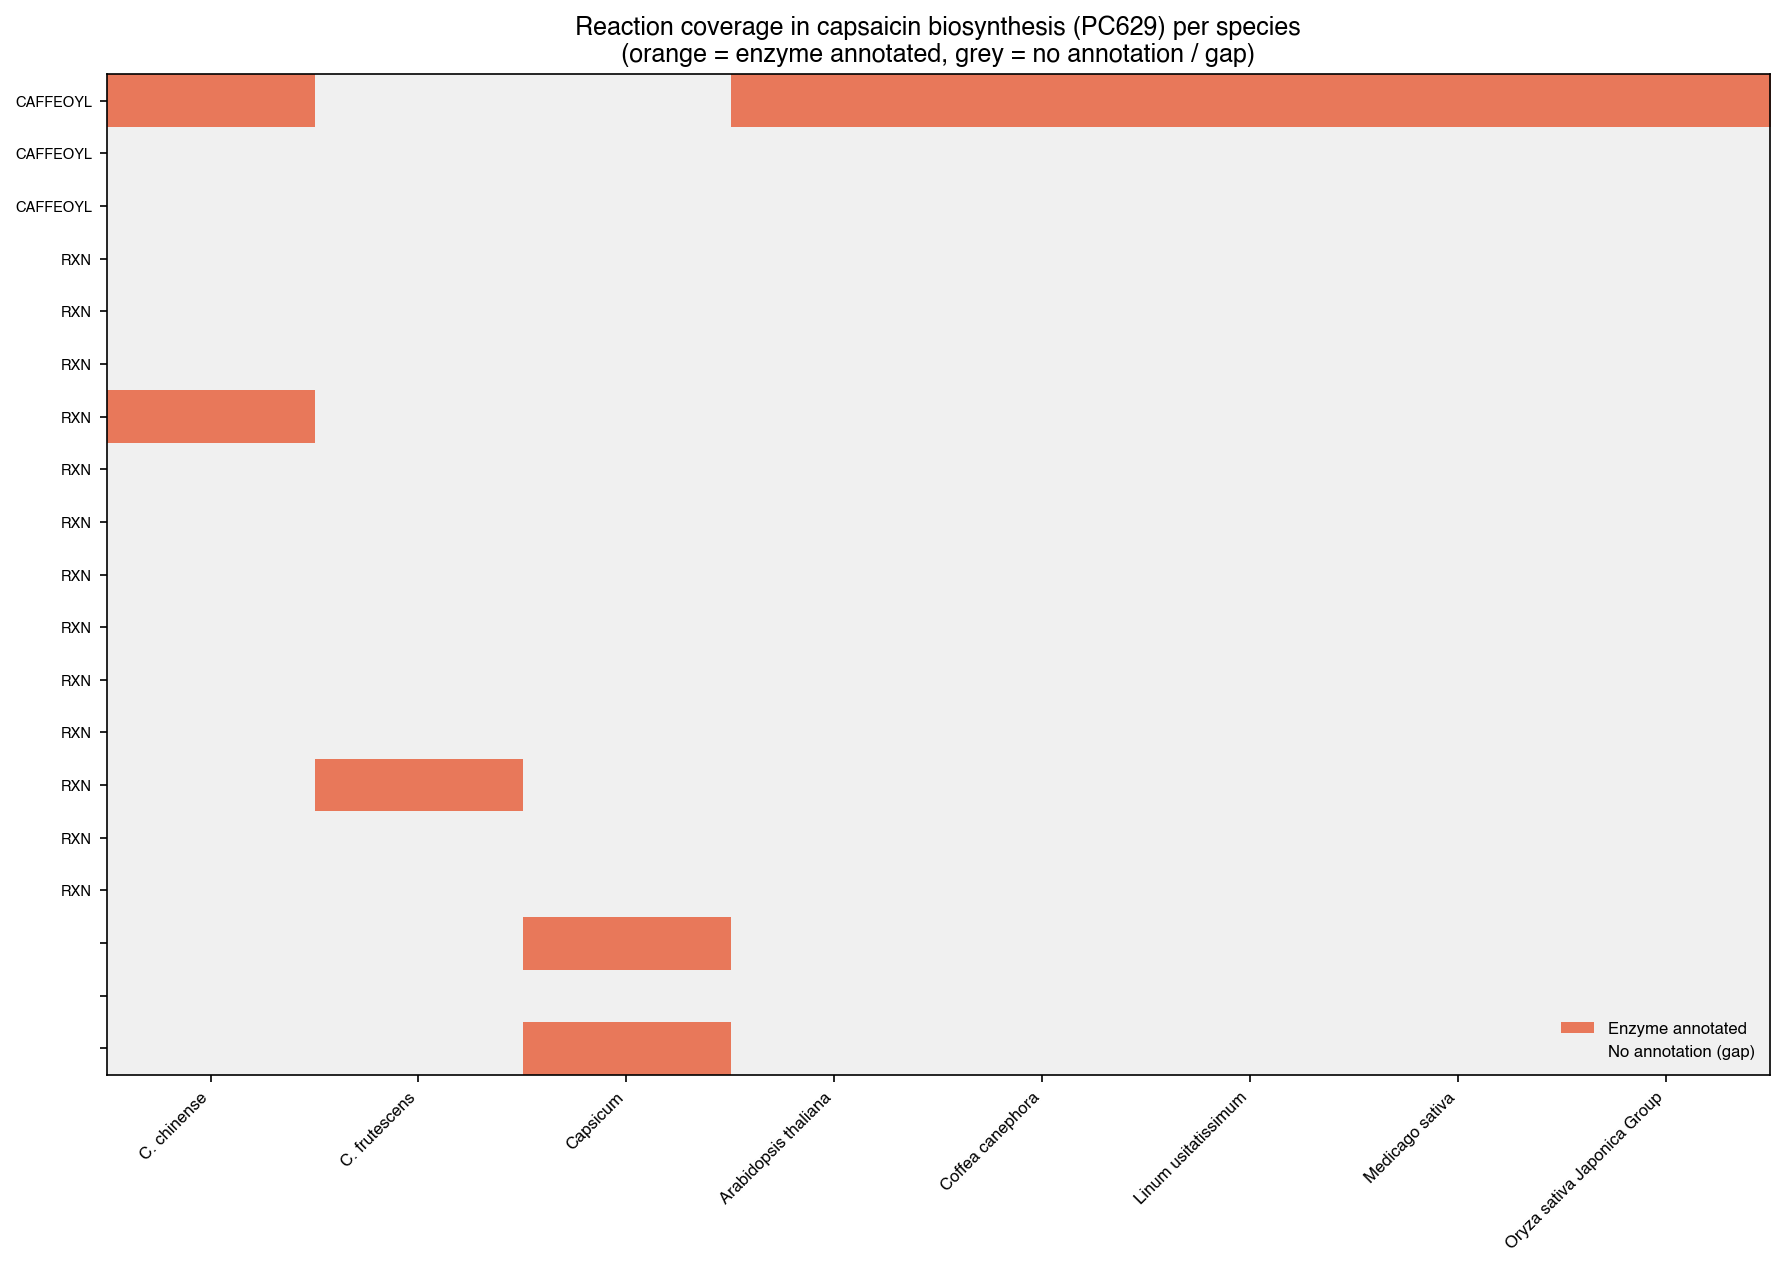

Matrix: 19 reactions x 8 species
Total annotated cells: 10 / 152


In [9]:
# All conversions in pathway
all_rxns = sparql(f"""
SELECT DISTINCT ?rxn (STR(?id) AS ?rxn_id)
WHERE {{
  GRAPH <{G_PW}> {{
    ?rxn a wp:Conversion ; dcterms:isPartOf <{PW629}> .
    OPTIONAL {{ ?rxn dc:identifier ?id }}
  }}
}}
""")
ensure_col(all_rxns, 'rxn_id', '')
# Short label: PlantCyc ID from identifier or IRI tail
all_rxns['label'] = all_rxns['rxn_id'].str.split('/').str[-1].where(
    all_rxns['rxn_id'] != '', all_rxns['rxn'].str.split('/').str[-1].str.split('_').str[0])

# Species→reaction coverage via wp:Catalysis
covered = sparql(f"""
SELECT DISTINCT ?species_name ?rxn
WHERE {{
  GRAPH <{G_TAX}> {{ ?enzyme wp:organism ?taxon . FILTER(?taxon != ncbi:33090) }}
  GRAPH <{G_PW}>  {{
    ?enzyme dcterms:isPartOf <{PW629}> .
    ?cat a wp:Catalysis ; wp:source ?enzyme ; wp:target ?rxn .
    ?rxn a wp:Conversion ; dcterms:isPartOf <{PW629}> .
  }}
  GRAPH <{G_NCBI}> {{ ?taxon rdfs:label ?species_name }}
}}
""")

# Build coverage matrix
species_order = ['Capsicum annuum','Capsicum chinense','Capsicum frutescens','Capsicum',
                 'Arabidopsis thaliana']
species_in_data = [s for s in species_order if s in covered['species_name'].values]
all_sp = sorted(set(covered['species_name']) - set(species_order))
species_cols = species_in_data + all_sp

rxn_label_map = dict(zip(all_rxns['rxn'], all_rxns['label']))
row_labels = [rxn_label_map.get(r, r.split('/')[-1]) for r in all_rxns['rxn']]
matrix = pd.DataFrame(0, index=all_rxns['rxn'].tolist(), columns=species_cols)
for _, row in covered.iterrows():
    if row['rxn'] in matrix.index and row['species_name'] in matrix.columns:
        matrix.loc[row['rxn'], row['species_name']] = 1
matrix.index = row_labels

# Visualise
from matplotlib.patches import Patch
fig, ax = plt.subplots(figsize=(max(8, len(species_cols)*1.5), max(5, len(matrix)*0.45)))
cmap = mpl.colors.ListedColormap(['#f0f0f0','#e8785a'])
ax.imshow(matrix.values, cmap=cmap, aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(species_cols)))
ax.set_xticklabels([s.replace('Capsicum ','C. ') for s in species_cols],
                   rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(matrix)))
ax.set_yticklabels(matrix.index, fontsize=7)
ax.set_title('Reaction coverage in capsaicin biosynthesis (PC629) per species\n'
             '(orange = enzyme annotated, grey = no annotation / gap)')
ax.legend(handles=[Patch(facecolor='#e8785a', label='Enzyme annotated'),
                   Patch(facecolor='#f0f0f0', label='No annotation (gap)')],
          loc='lower right', frameon=False, fontsize=8)
plt.tight_layout()
import pathlib; pathlib.Path('figures/output/figures').mkdir(parents=True, exist_ok=True)
plt.savefig('figures/output/figures/capsaicin_species_coverage_matrix.pdf', bbox_inches='tight')
plt.savefig('figures/output/figures/capsaicin_species_coverage_matrix.svg', bbox_inches='tight')
plt.show()
print(f"Matrix: {len(matrix)} reactions x {len(species_cols)} species")
print(f"Total annotated cells: {int(matrix.sum().sum())} / {len(matrix)*len(species_cols)}")


> **Key result:** The coverage matrix reveals which enzymatic steps are annotated per species
> and — crucially — which steps are **gaps** (grey cells).
>
> *Capsicum annuum* has **no annotated enzymes** in this pathway despite being the most
> well-annotated *Capsicum* species in the database overall. This represents a genuine
> annotation gap: the capsaicin pathway is present in *C. annuum* biochemically, but no
> enzyme nodes have been curated in this species's PlantCyc database for this pathway.
>
> Steps annotated in *C. chinense*, *C. frutescens*, or the genus *Capsicum* provide
> **cross-species evidence** that can be transferred to *C. annuum* via shared reactions.


---
## Step 8 — Shared metabolites: the chemical backbone common to all species

Metabolites in PlantMetWiki carry no direct species annotation — they are shared across
the pathway. This makes them ideal anchors for cross-species inference: a metabolite
present in the pathway is implicitly relevant to **all species** with any annotation in it.


In [10]:
metabolites_df = sparql(f"""
SELECT ?metabolite (STR(?mid) AS ?identifier) (STR(?lbl) AS ?label)
WHERE {{
  GRAPH <{G_PW}> {{
    ?metabolite a wp:Metabolite ; dcterms:isPartOf <{PW629}> .
    OPTIONAL {{ ?metabolite dc:identifier ?mid }}
    OPTIONAL {{ ?metabolite rdfs:label    ?lbl }}
  }}
}}
ORDER BY ?lbl
""")
ensure_col(metabolites_df, 'label', '')
ensure_col(metabolites_df, 'identifier', '')

print(f'{len(metabolites_df)} metabolites in PC629 (shared across all species):')
print()
for _, row in metabolites_df.iterrows():
    lbl = row['label'] or row['identifier'].split('/')[-1]
    mid = row['identifier'].replace('https://identifiers.org/inchikey/','InChIKey:')
    print(f'  {lbl:45s}  {mid}')


27 metabolites in PC629 (shared across all species):

  (E)-8-methylnon-6-enoate                       InChIKey:OCALSPDXYQHUHA-FNORWQNLSA-M
  (E)-8-methylnon-6-enoyl-CoA                    InChIKey:JGNCYWQFXLYWMO-RSERDAIDSA-J
  (E)-caffeoyl-CoA                               InChIKey:QHRGJMIMHCLHRG-ZSELIEHESA-J
  3-hydroxy-3-(4-hydroxy-3-methoxyphenyl)propanoyl-CoA  InChIKey:SDNPOBCYTJKZSD-XWQDBIPASA-J
  ADP                                            InChIKey:XTWYTFMLZFPYCI-KQYNXXCUSA-K
  ATP                                            InChIKey:ZKHQWZAMYRWXGA-KQYNXXCUSA-J
  Ca²⁺                                           InChIKey:BHPQYMZQTOCNFJ-UHFFFAOYSA-N
  Co²⁺                                           InChIKey:XLJKHNWPARRRJB-UHFFFAOYSA-N
  Cu²⁺                                           InChIKey:JPVYNHNXODAKFH-UHFFFAOYSA-N
  H⁺                                             InChIKey:GPRLSGONYQIRFK-UHFFFAOYSA-N
  H₂O                                            InChIKey:XLYOFNOQVPJJNP-UHFFFA

> **Observation:** 27 metabolites are present in PC629, linked to InChIKey identifiers
> (enabling cross-database lookups via BridgeDB). Key pathway intermediates include
> **vanillylamine**, **feruloyl-CoA**, **capsaicin** itself, and cofactors (CoA, NADPH, SAM).
>
> Because these metabolites carry no `wp:organism` tag, they are attributed to **all 9 species**
> in the pathway via the indirect co-occurrence strategy (see Figure 6b in the figures notebook).


---
## Step 9 — Cross-species inference: using related species to fill annotation gaps

We now ask: for each reaction gap in *C. annuum*, is there evidence from a related species
in the same pathway? We identify reactions with annotations in at least one other
*Capsicum* species (or phylogenetically related species) but not in *C. annuum*.


In [11]:
CAP_ANNUUM = 'http://purl.obolibrary.org/obo/NCBITaxon_4072'

covered_by_others = sparql(f"""
SELECT DISTINCT ?rxn ?evidence_species
WHERE {{
  GRAPH <{G_PW}> {{ ?rxn a wp:Conversion ; dcterms:isPartOf <{PW629}> }}
  GRAPH <{G_TAX}> {{ ?enzyme wp:organism ?evidence_taxon . FILTER(?evidence_taxon != ncbi:33090) }}
  GRAPH <{G_PW}>  {{
    ?enzyme dcterms:isPartOf <{PW629}> .
    ?cat a wp:Catalysis ; wp:source ?enzyme ; wp:target ?rxn .
  }}
  GRAPH <{G_NCBI}> {{ ?evidence_taxon rdfs:label ?evidence_species }}
  FILTER NOT EXISTS {{
    GRAPH <{G_TAX}> {{ ?ca_enzyme wp:organism <{CAP_ANNUUM}> }}
    GRAPH <{G_PW}>  {{
      ?ca_enzyme dcterms:isPartOf <{PW629}> .
      ?ca_cat a wp:Catalysis ; wp:source ?ca_enzyme ; wp:target ?rxn .
    }}
  }}
}}
ORDER BY ?rxn ?evidence_species
""")

if not covered_by_others.empty:
    covered_by_others['rxn_short'] = covered_by_others['rxn'].str.split('/').str[-1].str.split('_').str[0]
    print(f'{len(covered_by_others)} (reaction, species) inference pairs:')
    print(covered_by_others[['rxn_short','evidence_species']].to_string(index=False))
else:
    print('All reactions are gaps for C. annuum (no enzyme annotations in PC629).')
    print()
    print('Evidence from other Capsicum species for these gaps:')
    for _, row in rxn_per_sp.iterrows():
        print(f"  {row.get('rxn_short', row['rxn'].split('/')[-1]):25s}  via {row['species_name']}")


10 (reaction, species) inference pairs:
rxn_short            evidence_species
 CAFFEOYL        Arabidopsis thaliana
 CAFFEOYL           Capsicum chinense
 CAFFEOYL            Coffea canephora
 CAFFEOYL         Linum usitatissimum
 CAFFEOYL             Medicago sativa
 CAFFEOYL Oryza sativa Japonica Group
      RXN           Capsicum chinense
      RXN         Capsicum frutescens
                             Capsicum
                             Capsicum


> **Cross-species inference result:**
> Since *Capsicum annuum* has no annotations in PC629, **all 19 conversion steps** are
> potential inference targets. The reactions already annotated in *C. chinense*, *C. frutescens*,
> and the genus *Capsicum* provide the strongest transfer candidates, as they represent
> the same biochemical pathway in closely related taxa.
>
> The 6 *Arabidopsis thaliana* annotations provide additional phylogenetic evidence for
> enzyme–reaction assignments that may be conserved across Solanaceae.
>
> This analysis demonstrates that PlantMetWiki enables **structured gap identification**:
> by querying the knowledge graph, researchers can prioritise which enzyme–reaction pairs
> to target for experimental validation or computational gene-function prediction in *C. annuum*.


---
## Summary

| Question | Answer |
|----------|--------|
| *Capsicum* species in PlantMetWiki | 4 (genus + 3 species) |
| *C. annuum* total pathways | 34 |
| **Is capsaicin biosynthesis (PC629) annotated for *C. annuum*?** | **No — zero directly annotated nodes** |
| Species annotated in PC629 | 9 (incl. *C. chinense*, *C. frutescens*, *Arabidopsis*) |
| Total reactions in PC629 | 19 `wp:Conversion` |
| Reactions with any *Capsicum* enzyme evidence | see matrix above |
| Metabolites in PC629 (shared) | 27 `wp:Metabolite` with InChIKey IDs |

**Take-home:** PlantMetWiki reveals that the capsaicin biosynthesis pathway exists in the
knowledge graph with multi-species evidence, but the primary commercial pepper species
(*C. annuum*) lacks direct enzyme annotations in this pathway. Cross-species inference
using shared reactions and metabolites — enabled by the PlantMetWiki multi-graph RDF
architecture — identifies concrete enzyme–reaction targets for annotation transfer.

### SPARQL endpoint (public)
```
https://sparql-plantmetwiki.bioinformatics.nl/sparql
```
All queries in this notebook can be run directly against the public endpoint by replacing
`http://localhost:8890/sparql` with the URL above.
